### Clusterização - Parte 2 ###

### 1. Principais Algoritmos de Clusterização ###

A clusterização é a principal tarefa do aprendizado não supervisionado, cujo objetivo é agrupar instâncias de modo que os dados em um mesmo grupo sejam altamente similares entre si e dissimilares em relação aos outros grupos.

- **K-Means (Baseado em Centroide):** É um algoritmo particional que divide os dados em $K$ grupos não sobrepostos. Ele funciona de forma iterativa, definindo a posição de $K$ centroides (pontos representativos do centro de cada grupo) e minimizando a variância interna de cada cluster (métrica conhecida como **inércia**). O K-Means assume que os clusters são esféricos, têm tamanhos semelhantes e é muito sensível a outliers e efeitos de escala.

- **Clusterização Hierárquica:** Constrói uma hierarquia de clusters sem exigir a definição prévia do número de grupos. Essa estrutura é representada graficamente por uma árvore binária chamada **dendrograma**, que pode ser cortada em diferentes alturas para obter a quantidade ideal de clusters. Ele atua em duas estratégias:
    - **Aglomerativa *(bottom-up)*:** Cada ponto começa como seu próprio cluster individual e, iterativamente, os clusters mais próximos vão se fundindo.
    - **Divisiva *(top-down)*:** Começa com todos os pontos em um único grande grupo, dividindo-o de forma recursiva até que cada ponto seja seu próprio cluster.
    - Sua complexidade computacional é de $O(n^3)$, limitando seu uso a conjuntos de dados menores.
    
- **DBSCAN (Baseado em Densidade):** Define clusters como regiões contínuas de alta densidade separadas por áreas menos densas. Suas principais vantagens são a capacidade de identificar clusters de formatos geométricos arbitrários e a detecção nativa de anomalias/outliers, que são isolados e rotulados como ruído (valor -1). Seu custo computacional típico é de $O(n \log n)$ com indexação espacial eficiente.

### 2. Gaussian Mixture Models (GMM) e o Soft Clustering ### 

Diferente do K-Means, que realiza um agrupamento rígido (hard clustering — onde cada dado pertence estritamente a um único grupo), o **GMM** é um algoritmo paramétrico e probabilístico baseado em **soft clustering**. Em vez de associar uma instância a uma classe fixa, ele calcula a **probabilidade de pertencimento** de cada instância a cada um dos componentes.

O GMM assume que os dados são gerados a partir de uma mistura de $K$ distribuições normais (gaussianas) multivariadas. Cada componente gaussiana $k$ é definida por três parâmetros fundamentais:

1. **Vetor de Médias ($\mu_k$):** O centro geométrico da distribuição.

2. **Matriz de Covariância ($\Sigma_k$):** Representa a dispersão e a correlação entre as variáveis. Ela permite que os clusters assumam formatos **elípticos, oblíquos e tenham diferentes tamanhos e orientações** no espaço7more_horiz.Peso de Mistura ($\pi_k$): A proporção relativa de dados que pertencem a essa gaussiana específica.


**O Algoritmo de Expectation-Maximization (EM)**

Para aprender estes parâmetros, o GMM utiliza o algoritmo iterativo **EM**:

- **E-step (Expectation):** Calcula as "responsabilidades" ($\gamma_{ik}$), ou seja, a probabilidade do ponto de dado $x_i$ ter sido gerado pela gaussiana $k$, dados os parâmetros atuais do modelo.

- **M-step (Maximization):** Atualiza os parâmetros ($\mu_k$, $\Sigma_k$ e $\pi_k$) para maximizar a verossimilhança dos dados, ponderando cada instância pela sua respectiva responsabilidade calculada no passo anterior.


**Determinando o Número Ideal de Gaussianas**

Como é um modelo probabilístico, o número de clusters não pode ser determinado pela inércia (que é inadequada para gaussianas não esféricas). Em vez disso, utilizamos critérios de informação que penalizam a complexidade para evitar o sobreajustamento *(overfitting)*:

- **AIC (Akaike Information Criterion):** $AIC = 2k - 2\ln(L)$.
- **BIC (Bayesian Information Criterion):** $BIC = \ln(n)k - 2\ln(L)$ (aplica uma penalização mais forte baseada no número de pontos $n$).
- O objetivo é testar diferentes valores de $K$ e escolher o modelo que **minimiza** o valor de AIC ou BIC.

### 3. Sensibilidade do K-Means à Inicialização e o Papel do K-Means++ ###

O K-Means padrão seleciona suas sementes (centroides) iniciais de forma completamente aleatória (geralmente escolhendo $K$ instâncias ao acaso). Essa abordagem possui um problema grave:

- **Mínimos Locais (Sub-ótimos):** Como o K-Means é garantido a convergir, mas sua convergência é extremamente sensível à posição inicial dos centroides, uma escolha infeliz de sementes iniciais pode prender o algoritmo em **mínimos locais** (soluções sub-ótimas), resultando em agrupamentos bizarros que dividem clusters naturais ao meio.


**A Solução do K-Means++**

Para mitigar isso, Arthur e Vassilvitskii (2006) propuseram o **K-Means++**, uma técnica de inicialização inteligente que escolhe centroides distantes entre si. O algoritmo funciona assim:

1. **Primeiro Centroide ($c^{(1)}$):** É selecionado de forma uniforme e puramente aleatória a partir das instâncias do conjunto de dados.

2. **Próximos Centroides ($c^{(i)}$):** Para cada ponto $x_i$, calcula-se a distância $D(x_i)$ até o centroide mais próximo já escolhido. O próximo centroide é selecionado com probabilidade proporcional ao quadrado dessa distância: 
$$P(x_i) = \frac{D(x_i)^2}{\sum_{j=1}^{m} D(x_j)^2}$$

3. **Repetição:** Repete-se o processo até que todos os $K$ centroides sejam escolhidos.

Essa formulação garante matematicamente que pontos localizados mais longe de centroides já existentes sejam muito mais propensos a serem escolhidos como novas sementes, acelerando a convergência e reduzindo drasticamente a probabilidade de cair em mínimos locais ruins.

### 4. DBSCAN: Como eps e min_samples Definem o Comportamento ### 

O DBSCAN é controlado por apenas dois hiperparâmetros fundamentais que definem a estrutura geométrica da densidade local:

- **eps (raio de vizinhança $\epsilon$):** Define a distância máxima para que dois pontos sejam considerados vizinhos diretos.
- **min_samples (mínimo de pontos):** O número mínimo de pontos (incluindo o próprio ponto) que devem estar contidos dentro do raio eps para caracterizar uma região como "densa".

Com base nesses parâmetros, o DBSCAN classifica cada ponto do conjunto de dados em três categorias:

1. **Ponto Central *(Core Point)*:** Possui pelo menos min_samples pontos dentro de sua vizinhança eps.
2. **Ponto de Borda *(Border Point)*:** Não possui o número mínimo de vizinhos, mas está localizado dentro da vizinhança de algum *Core Point*.
3. **Ponto de Ruído/Outlier *(Noise Point)*:** Não é um ponto central e nem está na vizinhança de um ponto central.


**Como isso gera clusters de formato arbitrário?**

A formação do cluster começa em um ponto central aleatório. O algoritmo se expande de forma "contagiosa": se um ponto central estiver no raio eps de outro ponto central, eles são conectados e passam a fazer parte do mesmo cluster (formando uma cadeia densa chamada **alcance de densidade**).

- **Formatos Arbitrários:** Como não há centroides ou pressuposição de formatos esféricos, as conexões entre pontos centrais vizinhos se estendem em qualquer direção em que a densidade seja contínua, permitindo mapear formas complexas (como círculos concêntricos ou formatos de lua).
- **Identificação de Ruído:** Qualquer ponto localizado em regiões de baixa densidade (que não atinge o critério de vizinhos de nenhum ponto central) é imediatamente isolado como outlier.

### 5. Clusterização Hierárquica: Tipos de Linkage e a Forma dos Clusters ###

No agrupamento hierárquico, a matriz de distâncias original nos diz como medir o afastamento entre pontos individuais, mas para fundir clusters compostos por múltiplos elementos, precisamos definir o ***Critério de Ligação (Linkage).*** A escolha do *linkage* dita a geometria e o comportamento dos clusters formados:

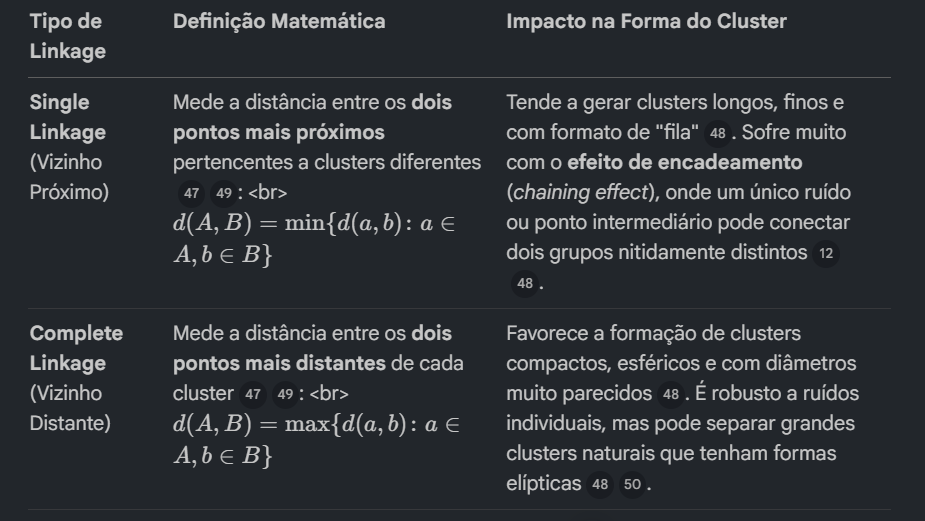
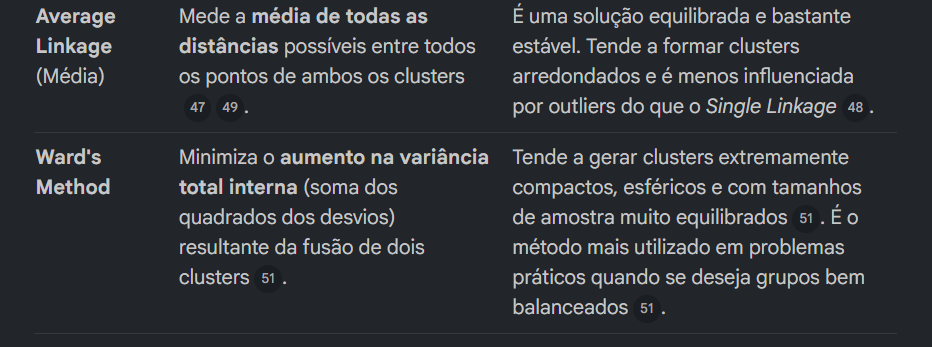

### 6. Método do Cotovelo (Elbow Method) ###

O método do cotovelo avalia o desempenho de um algoritmo (como o K-Means) analisando a inércia (ou a soma dos erros quadráticos intra-cluster — Within-Cluster Sum-of-Squares) à medida que aumentamos o número de clusters $K$.

- **O Funcionamento:** A **inércia** mede a soma das distâncias quadráticas entre cada ponto de dado e o seu centroide mais próximo. Conforme o $K$ aumenta, a inércia inevitavelmente diminui (se tivermos um cluster para cada ponto, a inércia será exatamente zero).

- **A Regra do Cotovelo:** Plotamos a inércia em função de $K$. O gráfico resultante costuma ter o formato de um braço dobrado. Procuramos o **ponto de inflexão (o "cotovelo")**, que representa o ponto em que a adição de mais clusters deixa de trazer um ganho significativo na redução da inércia.

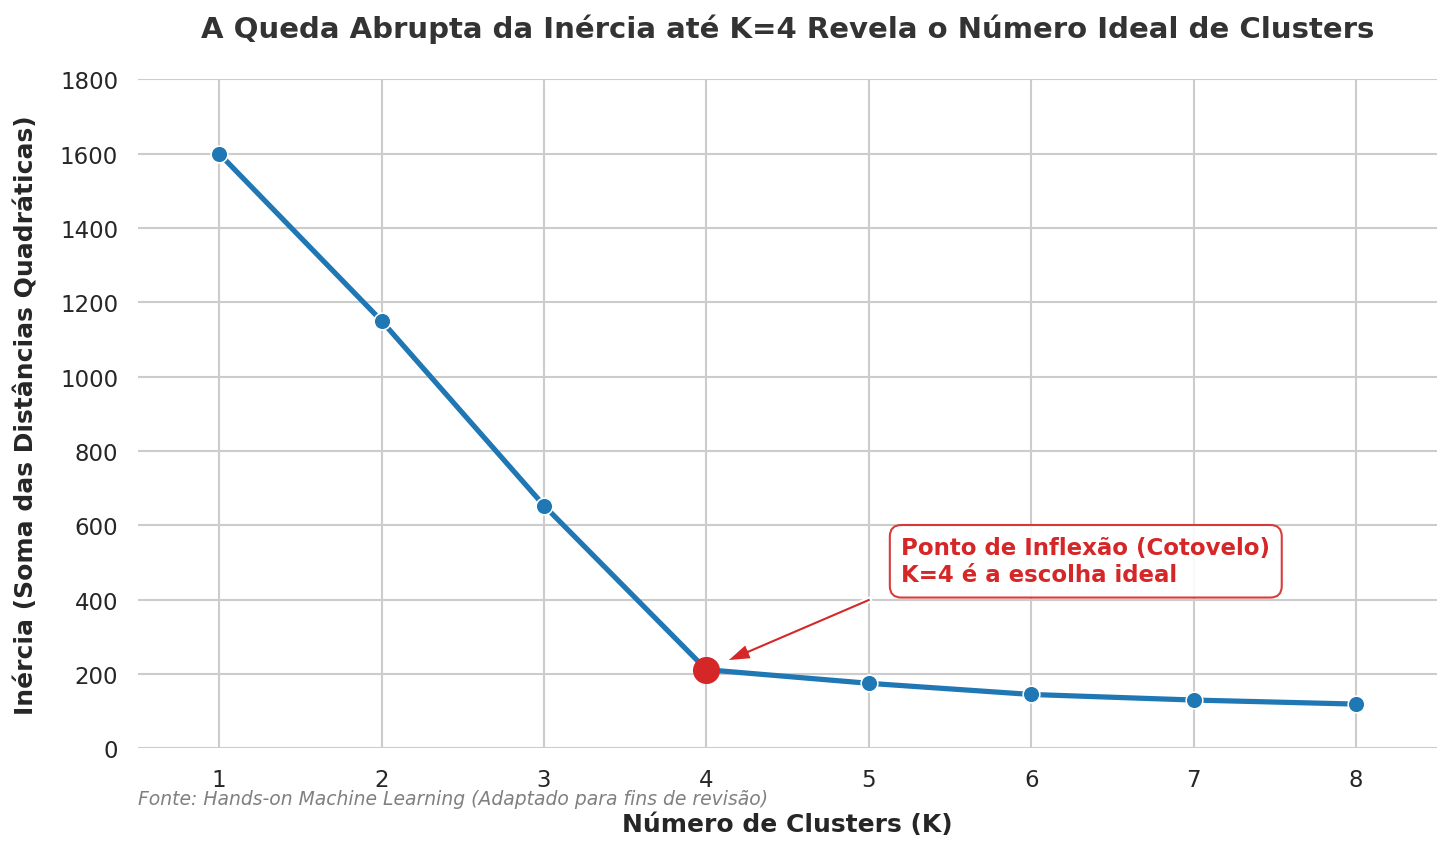

- **Limitação:** É uma métrica puramente visual e grosseira. Em dados muito dispersos ou complexos, o "cotovelo" pode ser suave e difícil de identificar com precisão.

### 7. Coeficiente de Silhueta (Silhouette Score) ### 

A análise de silhueta é uma abordagem muito mais refinada que o método do cotovelo, pois avalia simultaneamente duas propriedades fundamentais de um cluster: **a coesão** (proximidade interna) e a **separação** (distância para outros grupos).

- **A Matemática:** Para cada instância $i$, calculamos o coeficiente de silhueta $s(i)$ através da fórmula: $$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$ 

Onde:
    
- $a(i)$ é a distância média entre o ponto $i$ e todos os outros pontos do mesmo cluster (medida de coesão).
- $b(i)$ é a menor distância média entre o ponto $i$ e todos os pontos do **cluster vizinho mais próximo** (medida de separação).
    
- **Interpretação do Domínio [-1, 1]:**
    - **Próximo a +1:** Indica que a instância está bem no interior do seu próprio cluster e muito distante dos clusters vizinhos (excelente agrupamento).
    - **Próximo a 0:** Significa que o ponto está localizado na fronteira de decisão entre dois clusters.
    - **Próximo a -1:** Indica que a instância provavelmente foi atribuída ao cluster errado.
    
- **O Silhouette Score Global:** É a **média simples** do coeficiente de silhueta de todas as instâncias do conjunto de dados. Além disso, o **diagrama de silhueta** permite verificar graficamente se há clusters de tamanhos muito desproporcionais ou se algum grupo específico está performando abaixo da média global.

### 8. Gap Statistic ###

A estatística de Gap (proposta por Tibshirani, Walther e Hastie em 2001) formaliza a escolha do $K$ ideal comparando a estrutura observada com uma distribuição de **referência nula** (sem clusters).

- **O Funcionamento:** O algoritmo calcula a inércia intra-cluster logarítmica $\log(W_k)$ dos seus dados reais para diferentes valores de $K$. Em seguida, ele gera múltiplos conjuntos de dados sintéticos de referência (usando uma distribuição uniforme sobre a caixa delimitadora dos dados originais) e calcula a inércia média esperada $\log(W_{kb}^*)$ sob essa hipótese nula.
- **A Fórmula:** $$\text{Gap}(k) = E_1^*\{\log(W_k^*)\} - \log(W_k)$$
- **Interpretação:** O valor ideal de $K$ é aquele que **maximiza a estatística de Gap**, ou seja, o ponto onde a estrutura de agrupamento observada nos seus dados reais se afasta ao máximo da dispersão aleatória esperada ao acaso.

### 9. Índice de Davies-Bouldin (DBI) ### 

O índice de Davies-Bouldin é uma métrica de validação interna focada na razão entre a dispersão interna de cada cluster e a distância entre seus respectivos centroides.

- **A Matemática:** O índice é calculado obtendo-se a similaridade máxima de cada cluster $i$ em relação ao seu pior parceiro $j$: $$DBI = \frac{1}{k} \sum_{i=1}^{k} \max_{j \neq i} \left( \frac{\sigma_i + \sigma_j}{d(c_i, c_j)} \right)$$ 

Onde:
    - $\sigma_i$ é a distância média de todos os pontos do cluster $i$ até o seu centroide $c_i$ (representa a dispersão interna).
    - $d(c_i, c_j)$ é a distância euclidiana simples entre os centroides $c_i$ e $c_j$.
    
- **Interpretação: Quanto menor o valor de DBI, melhor é o agrupamento**. Um DBI baixo indica que os clusters são muito compactos (pequeno $\sigma$) e estão bem distantes uns dos outros (grande $d$).
- **Limitação:** É altamente sensível a ruídos e à presença de outliers, que inflam artificialmente a média de dispersão $\sigma$.

### 10. Índice de Calinski-Harabasz *(Variance Ratio Criterion)* ### 

O índice de Calinski-Harabasz mede a qualidade do agrupamento calculando a **razão de variância** entre a dispersão global entre clusters e a dispersão interna dos clusters.

- **A Matemática:** $$CH = \frac{B_k}{W_k} \times \frac{n - k}{k - 1}$$

Onde:
    
- $B_k$ é a matriz de dispersão entre clusters (*Between-group sum of squares* — soma das distâncias quadradas ponderadas entre os centroides de cada cluster e o centroide global de todos os dados).
- $W_k$ é a inércia interna ou dispersão **dentro dos clusters** *(Within-group sum of squares)*.
- $n$ é o número total de amostras e $k$ é a quantidade de clusters.

- **Interpretação: Valores maiores de CH indicam clusters mais bem definidos e densos**. Um CH alto significa que a variabilidade entre os grupos é muito maior do que a variabilidade interna de cada grupo.
- **Vantagem e Limitação:** É computacionalmente muito rápido e excelente para avaliar clusters de formatos esféricos e densidades homogêneas, mas perde eficácia quando os agrupamentos assumem formatos geométricos complexos ou alongados (como as luas que visualizamos).

### 11. Dendrograma: A "Régua" do Agrupamento Hierárquico ###

- **O que é:** O dendrograma é a representação visual clássica da clusterização hierárquica, estruturada como uma árvore binária que mapeia todo o histórico de fusões ou divisões do algoritmo.

- **Como escolher $K$ na prática:** Diferente do K-Means, onde você precisa definir o número de grupos previamente, no hierárquico você pode analisar a árvore e **"cortar" o dendrograma** horizontalmente em um determinado nível de distância ou dissimilaridade. A quantidade de ramos verticais que a sua linha de corte interceptar definirá o número final de clusters ($K$). Quanto mais alto o corte, mais dissimilares são os grupos que estão sendo separados.

### 12. PCA: Maximização de Variância e Ortogonalidade ###

- **Mecanismo Linear:** O PCA (Análise de Componentes Principais) é uma técnica geométrica e linear de redução de dimensionalidade.

- **Os Componentes Ortogonais:** Ele rotaciona e projeta os dados originais em novos eixos perpendiculares entre si (ortogonais), chamados de **Componentes Principais (PCs)**.

- **O Objetivo:** O primeiro componente (PC1) é calculado matemática e estatisticamente para alinhar-se com a direção que captura a **máxima variância explicada** (maior dispersão) dos dados originais. O PC2 é ortogonal ao PC1 e captura a maior variabilidade restante, e assim por diante.

### 13. Impacto do PCA na Clusterização: O Perigo da Escala ### 

- **A Vantagem:** O PCA é um excelente aliado da clusterização. Ao consolidar colunas correlacionadas [cite: 291] e descartar eixos com pouca variação, ele **reduz ruídos** e combate a **"maldição da dimensionalidade"** (onde a esparsidade dos dados em alta dimensão faz com que as distâncias entre todos os pontos pareçam iguais).

- **O Perigo Geométrico:** O PCA é extremamente sensível à escala das variáveis originais. Se você tiver uma variável com magnitude na casa dos milhões (ex: Renda) e outra na casa das dezenas (ex: Idade), o PCA focará quase todo o seu poder de projeção na Renda. Por isso, a **padronização prévia (Z-score) é estritamente obrigatória**. Sem ela, o PCA distorcerá as distâncias geométricas, gerando eixos enviesados que prejudicarão a clusterização subsequente.

### 14. t-SNE e UMAP vs. PCA: Diferença de Propósito e Escala ###

- **Preservação Local (t-SNE/UMAP):** São algoritmos não-lineares focados em **preservar a estrutura local de vizinhança**. Eles tentam garantir que pontos muito próximos no espaço multidimensional permaneçam próximos quando projetados em 2D ou 3D. Contudo, as distâncias globais entre clusters distantes no gráfico perdem o significado físico direto.

- **Preservação Global (PCA):** O PCA preserva a variância e a estrutura global dos dados, mantendo as distâncias em grande escala, sendo determinístico e altamente interpretável por meio das combinações lineares das variáveis originais.

- **Por que não usar t-SNE/UMAP no pré-processamento direto?** Diferente do PCA, o t-SNE não fornece uma função de projeção matemática direta simples para novos dados (out-of-sample). Se um novo cliente entrar na base amanhã, você não conseguirá aplicar a mesma transformação nele sem reprocessar o algoritmo. Por isso, t-SNE e UMAP são maravilhosos para **visualização (DataViz)** e exploração visual, mas o PCA e a engenharia de características tradicionais continuam sendo as opções seguras para pipelines de produção e modelagem.

### 15. O Trade-off da Redução de Dimensionalidade ###

Ao projetar seus dados em um espaço menor, você aceita uma troca clara de forças no seu projeto:

- **Os Ganhos (+):** Treinamento de algoritmos consideravelmente mais rápido, menor consumo de memória e armazenamento, simplificação de dados e combate ativo ao overfitting de ruídos.

- **As Perdas (-):** Perda inevitável de alguma parcela de informação original (variância descartada) e **perda de interpretabilidade das variáveis originais**. Explicar para um diretor de negócios o impacto de variáveis reais (como idade ou score de crédito) é simples; explicar o comportamento do "Componente Principal 1" (que é uma combinação abstrata de dezenas de colunas) é um grande desafio.